# Week-7

Decision trees and KNN

In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['font.size'] = 15

## Decision Trees

**Decision stumps**

A decision stump is a decision tree that has a single question at the root node which splits into two leaf nodes. A decision stump partitions the dataset based on a single question: $f_k < \theta$. This is therefore the simplest decision tree that we can come up with.

---
Use the following decision stump for problems 1 and 3: The root has $1000$ data-points out of which $200$ belong to class-1. The left child-node has $100$ data-points out of which $50$ belong to class-1.

### Problem-1

Write a function `entropy` that accepts the proportion of points that belong to class-1 in a node as argument and returns the entropy. Use $\log_2$ for all computations.

Use this function to compute the entropy of the parent node.

In [18]:
### Solution ###
def entropy(p):
    """
    Computes entropy of a node.

    Parameters
    ----------
    p : float
        Fraction of class-1 samples.

    Returns
    -------
    float
        Entropy of the node.
    """

    try:
        if type(p) != np.float64 and type(p) != np.int64 and type(p) != float and type(p) != int:
            raise TypeError("p must be a float or integer")

        if p < 0 or p > 1:
            raise ValueError("p must be between 0 and 1")

        if p == 0 or p == 1:
            return 0

        return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

    except TypeError as e:
        print(e)
        return None
    except ValueError as e:
        print(e)
        return None
    except Exception as e:
        print("An unexpected error occurred:", e)
        return None

### Problem-2

Plot the entropy of a node as a function of $p$, the proportion of data-points that belong to class $+1$.

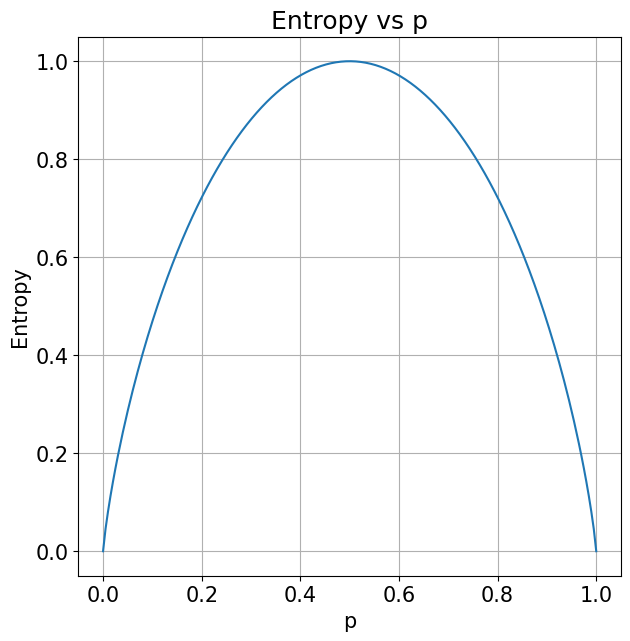

In [19]:
### Solution ###

# Generate values of p
p = np.linspace(0, 1, 200)

# Compute entropy
H = []

for value in p:
    H.append(entropy(value))

# Plot
plt.figure(figsize=(7,7))
plt.plot(p, H)

plt.xlabel("p")
plt.ylabel("Entropy")
plt.title("Entropy vs p")

plt.grid(True)

plt.show()

### Problem-3

Write a function `IG` that accepts the following arguments:

- `E`: entropy of the parent node `Q`
- `El`: entropy of the left child `L`
- `Er`: entropy of the right child `R`
- `gamma`: proportion of data-points in left child

Use this function to compute the information gain for the parent node.

In [20]:
### Solution ###

def IG(E, El, Er, gamma):
    """
    Computes Information Gain.

    Parameters
    ----------
    E : float
        Entropy of parent node.

    El : float
        Entropy of left child.

    Er : float
        Entropy of right child.

    gamma : float
        Fraction of samples in left child.

    Returns
    -------
    float
        Information Gain.
    """

    return E - (gamma * El + (1 - gamma) * Er)

### Problem-4

Consider a decision stump with $1000$ data-points. Call the root node $Q$ and the left and right leaf nodes $L$ and $R$.

- The proportion of data-points that belong to class $+1$ in $Q$ is equal to $0.4$
- The proportion of points in the left node is equal to $0.7$, that is, $\gamma = 0.7$
-  $q$ is the proportion of data-points that belong to class $+1$ in $L$

What are the minimum ($q_{\min}$) and maximum ($q_{\max}$) values of $q$?

In [25]:
### Solution ###

# Total number of samples
n = 1000

# Parent positive proportion
p = 0.4

# Fraction of samples in left child
gamma = 0.7

# Number of samples
left = int(gamma * n)
right = n - left

# Total positive samples
positive = int(p * n)

# Maximum possible positives in left child
max_positive_left = min(left, positive)

# Minimum possible positives in left child
min_positive_left = max(0, positive - right)

# Required values
q_min = min_positive_left / left
q_max = max_positive_left / left

print("q_min =", q_min)
print("q_max =", q_max)

q_min = 0.14285714285714285
q_max = 0.5714285714285714


### Problem-5

Using the above information, plot the information gain of the root as a function of $q$, where $q \in [q_{\min}, q_{\max}]$. Record at least two interesting observations.

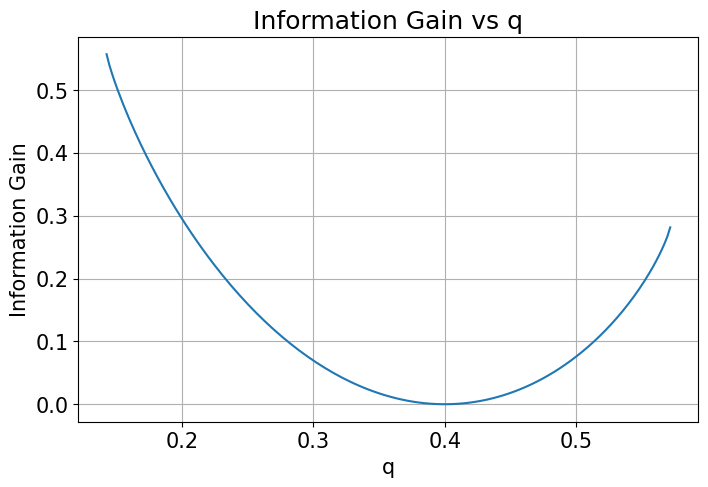

In [27]:

### Solution ###

# Parent entropy
E = entropy(0.4)

# Generate q values
q = np.linspace(q_min, q_max, 200)

# Empty list to store Information Gain
ig = []

# Loop through every q
for qi in q:

    # Entropy of left child
    El = entropy(qi)

    # Number of positive samples in left child
    positive_left = qi * 700

    # Remaining positives go to right child
    positive_right = 400 - positive_left

    # Positive proportion in right child
    r = positive_right / 300
    

    # Entropy of right child
    Er = entropy(r)

    # Compute Information Gain
    gain = IG(E, El, Er, gamma)

    ig.append(gain)

# Plot
plt.figure(figsize=(8,5))

plt.plot(q, ig)

plt.xlabel("q")
plt.ylabel("Information Gain")
plt.title("Information Gain vs q")

plt.grid(True)

plt.show()

### Problem-6

We will work with the dataset `X` for the next five problems. Visualize the data using a scatter plot. Color the points that belong to class $+1$ using "green" and those that belong to class $0$ using "red".

In [28]:
### Data ###
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###
rng = np.random.default_rng(seed = 1001)
n_per = 50
cov = np.eye(2) / 10
X1 = rng.multivariate_normal([1, 1], cov, n_per)
y1 = np.ones(n_per)
X2 = rng.multivariate_normal([5, 3], cov , n_per)
y2 = np.zeros(n_per)
X3 = rng.multivariate_normal([3, 4], cov, n_per)
y3 = np.ones(n_per)
X4 = rng.multivariate_normal([3, 2], cov, n_per)
y4 = np.zeros(n_per)
X = np.concatenate((X1, X2, X3, X4), axis = 0)
y = np.int64(np.concatenate((y1, y2, y3, y4)))
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###

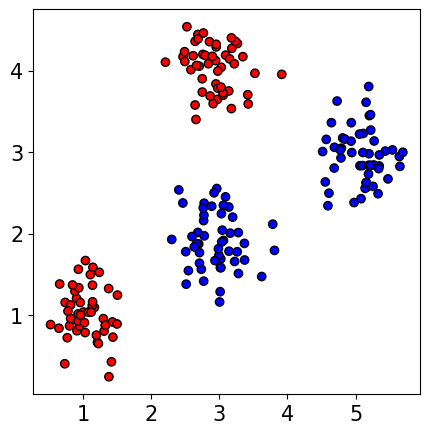

In [33]:
### Solution ###
plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'bwr', edgecolor = 'k')

### Problem-7

If you were to use a decision stump as a classifier:

- What is the best question $f_k < \theta$?
    - enter the feature index, $k$ (use zero-indexing)
    - enter the value of $\theta$
- What is the information gain for this question?

---

Write the function named `best_split` to solve this problem:

The function should accept the feature matrix `X` and the label vector `y` as arguements. It should return the tuple `(feat_best, value_best, ig_best)`.

In [35]:
def best_split(X, y):
    """
    Finds the best decision stump.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
    y : ndarray of labels

    Returns
    -------
    feat_best : int
        Best feature index.

    value_best : float
        Best threshold.

    ig_best : float
        Maximum information gain.
    """

    n_samples, n_features = X.shape

    # Parent entropy
    E = entropy(np.mean(y))

    feat_best = None
    value_best = None
    ig_best = -1

    # Loop over every feature
    for feat in range(n_features):

        values = np.sort(np.unique(X[:, feat])) 

        # Candidate thresholds = midpoints 
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:

            left = X[:, feat] < threshold
            right = ~left

            # Skip invalid split
            if np.sum(left) == 0 or np.sum(right) == 0:
                continue

            # Entropy of left child
            El = entropy(np.mean(y[left]))

            # Entropy of right child
            Er = entropy(np.mean(y[right]))

            # Fraction going left
            gamma = np.sum(left) / n_samples

            gain = IG(E, El, Er, gamma)

            if gain > ig_best:
                ig_best = gain
                feat_best = feat
                value_best = threshold

    return feat_best, value_best, ig_best

### Problem-8

Grow a decision tree for this problem. You may have to use two programming concepts:

- recursion
- binary trees

Once you have grown the tree, answer the following questions:

- How many internal nodes does your tree have?
- How many leaf nodes does it have?

In [36]:
### Solution ###
### Solution ###

class Node:

    def __init__(self,
                 feature=None,
                 threshold=None,
                 left=None,
                 right=None,
                 value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


def build_tree(X, y):

    # If all labels are same -> Leaf
    if len(np.unique(y)) == 1:
        return Node(value=int(y[0]))

    feat, thresh, ig = best_split(X, y)

    # If no useful split
    if feat is None:
        majority = int(np.round(np.mean(y)))
        return Node(value=majority)

    left_mask = X[:, feat] < thresh
    right_mask = ~left_mask

    left_child = build_tree(X[left_mask], y[left_mask])
    right_child = build_tree(X[right_mask], y[right_mask])

    return Node(
        feature=feat,
        threshold=thresh,
        left=left_child,
        right=right_child
    )


tree = build_tree(X, y)

In [40]:
def count_internal(node):

    if node is None:
        return 0

    if node.value is not None:
        return 0

    return 1 + count_internal(node.left) + count_internal(node.right)


def count_leaf(node):

    if node is None:
        return 0

    if node.value is not None:
        return 1

    return count_leaf(node.left) + count_leaf(node.right)

print("Internal Nodes :", count_internal(tree))
print("Leaf Nodes :", count_leaf(tree))

Internal Nodes : 3
Leaf Nodes : 4


### Problem-9

Predict the label of the point $(3, 4)$.

In [42]:
### Solution ###
### Solution ###

def predict(node, x):
    """
    Predict the class label for a single sample.
    """

    # If we reach a leaf node, return its label
    if node.value is not None:
        return node.value

    # Decide whether to go left or right
    if x[node.feature] < node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)


# Test point
test_point = np.array([3, 4])

prediction = predict(tree, test_point)

print("Predicted Label:", prediction)

Predicted Label: 1


### Problem-10

Plot the decision boundary.

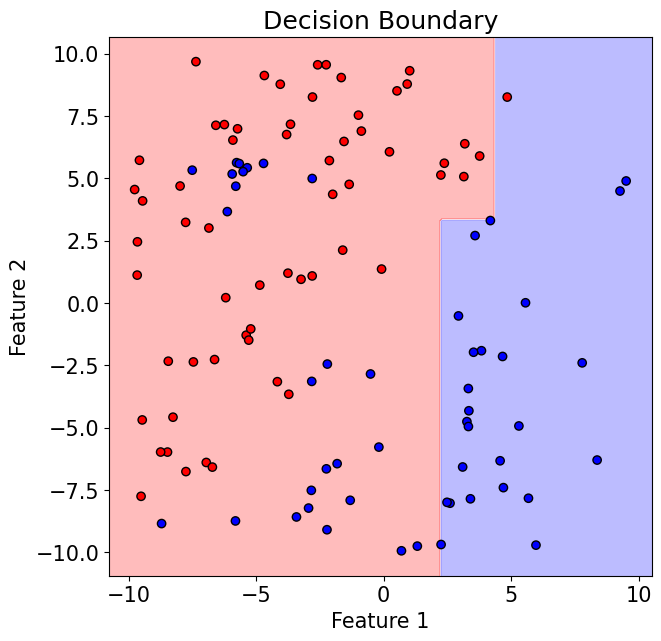

In [43]:


# Create a grid
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict every point on the grid
Z = []

for point in np.c_[xx.ravel(), yy.ravel()]:
    Z.append(predict(tree, point))

Z = np.array(Z)
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(7,7))

plt.contourf(xx, yy, Z,
             alpha=0.3,
             cmap="bwr")

# Plot training points
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")

plt.show()

## KNN


In [44]:
### Data ###
### DO NOT EDIT THIS CELL ###
rng = np.random.default_rng(seed = 1001)
X = rng.uniform(-10, 10, (100, 2))
y = np.int32(np.zeros(X.shape[0]))
y[X[:, 1] > X[:, 0]] = 1
X = np.concatenate((X,
                   rng.multivariate_normal([-5, 5], np.eye(2), 10)),
                   axis = 0)
y = np.concatenate((y, np.int32(np.zeros(10))))
### DO NOT EDIT THIS CELL ###

### Problem-11

Visualize the data using a scatter plot. Use red for class $0$ and green for class $1$.

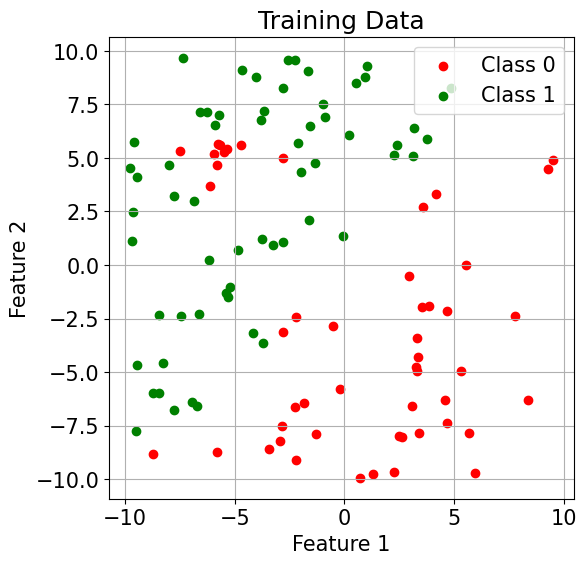

In [45]:
### Solution ###

plt.figure(figsize=(6,6))

# Class 0 -> Red
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="red",
    label="Class 0"
)

# Class 1 -> Green
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="green",
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data")

plt.legend()
plt.grid(True)

plt.show()

### Problem-12

Write a function `predict` that accepts the following arguments:

- `X` - feature matrix
- `y` - label vector
- `x_test` - test data-point
- `k` - number of neighbors

The function should return the prediction for the point `x_test`. Use this function to compute the predicted label for the point $(-3, -2)$ with $k = 10$.

In [46]:
### Solution ###

def predict(X, y, x_test, k):
    """
    Predicts the class label of x_test using k-NN.
    """

    # Compute Euclidean distances
    distances = np.sqrt(np.sum((X - x_test)**2, axis=1))

    # Indices of k nearest neighbours
    idx = np.argsort(distances)[:k]

    # Labels of neighbours
    labels = y[idx]

    # Majority vote
    prediction = np.bincount(labels).argmax()

    return prediction


# Test point
x_test = np.array([-3, -2])

prediction = predict(X, y, x_test, k=10)

print("Predicted Label :", prediction)

Predicted Label : 1


### Problem-13

Plot the decision boundary for different values of $k$:

- $k = 1$
- $k = 3$
- $k = 7$
- $k = 15$
- $k = 31$
- $k = 63$

Record at least two observations.

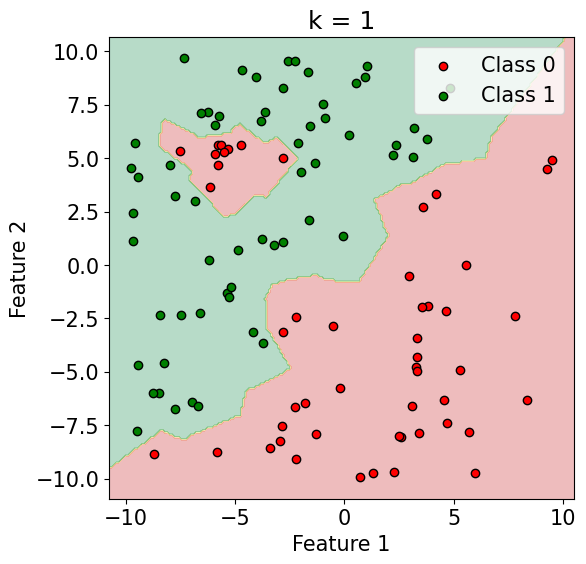

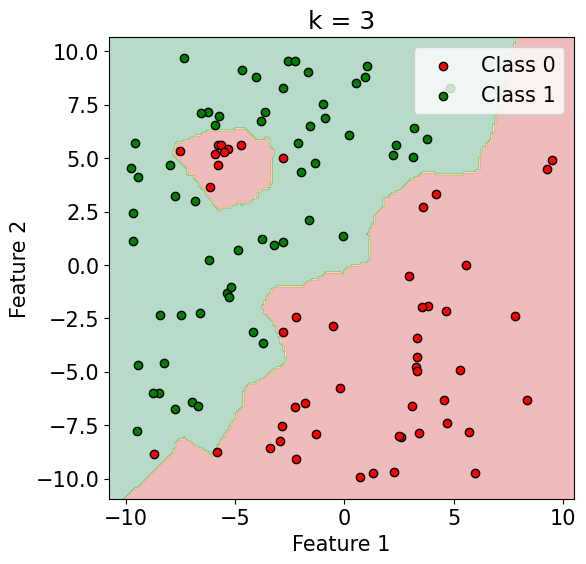

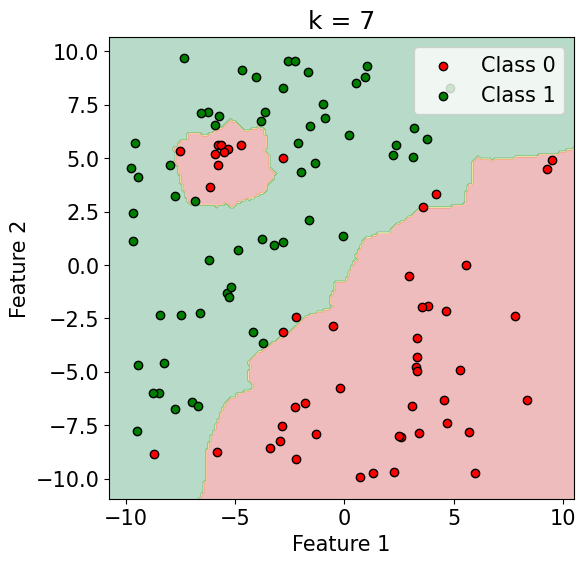

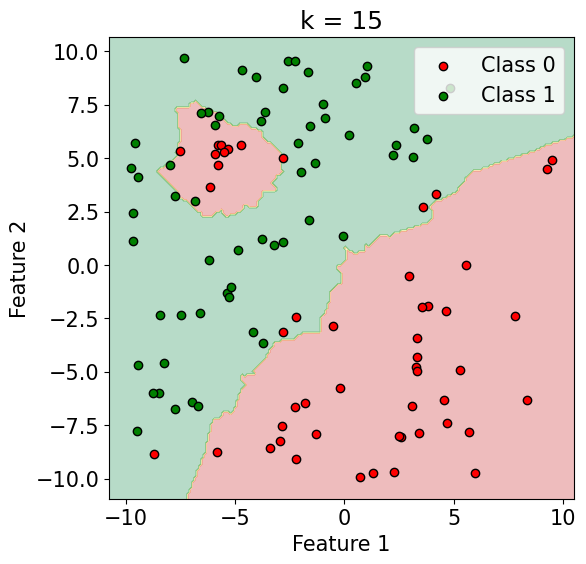

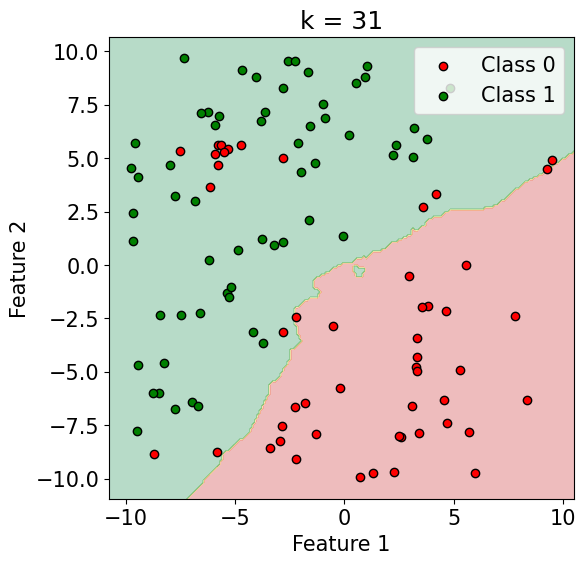

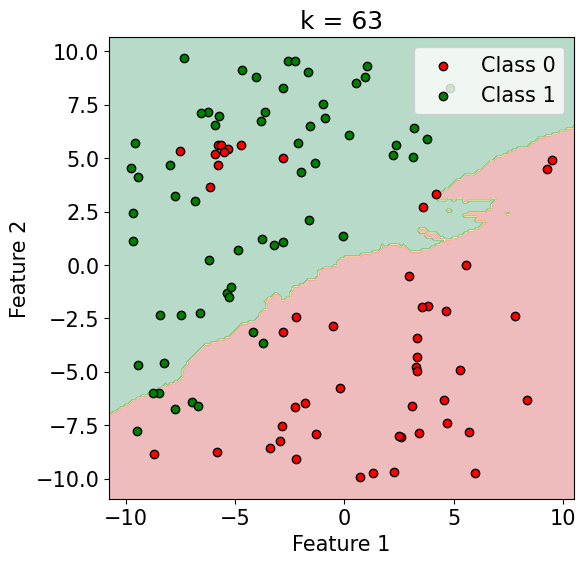

In [47]:
### Solution ###

k_values = [1, 3, 7, 15, 31, 63]

for k in k_values:

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = []

    for point in grid:
        Z.append(predict(X, y, point, k))

    Z = np.array(Z).reshape(xx.shape)

    plt.figure(figsize=(6,6))

    plt.contourf(xx, yy, Z,
                 alpha=0.3,
                 cmap="RdYlGn")

    plt.scatter(
        X[y==0,0],
        X[y==0,1],
        color="red",
        edgecolors="k",
        label="Class 0"
    )

    plt.scatter(
        X[y==1,0],
        X[y==1,1],
        color="green",
        edgecolors="k",
        label="Class 1"
    )

    plt.title(f"k = {k}")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

    plt.show()